In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [3]:
df = pd.read_csv("btcusd_1-min_data.csv")

df.head()

,Timestamp,Open,High,Low,Close,Volume
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7468963 entries, 0 to 7468962
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  float64
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
dtypes: float64(6)
memory usage: 341.9 MB


,Timestamp,Open,High,Low,Close,Volume
count,7.468963e+06,7.468963e+06,7.468963e+06,7.468963e+06,7.468963e+06,7.468963e+06
mean,1.549486e+09,2.246651e+04,2.247450e+04,2.245833e+04,2.246652e+04,5.071757e+00
std,1.293741e+08,3.083928e+04,3.084769e+04,3.083079e+04,3.083929e+04,2.185950e+01
min,1.325412e+09,3.800000e+00,3.800000e+00,3.800000e+00,3.800000e+00,0.000000e+00
25%,1.437446e+09,4.495500e+02,4.497500e+02,4.493500e+02,4.495650e+02,2.085326e-02
50%,1.549481e+09,7.571890e+03,7.576960e+03,7.567100e+03,7.572000e+03,4.560601e-01
75%,1.661515e+09,3.489700e+04,3.491543e+04,3.487749e+04,3.489700e+04,2.872836e+00
max,1.773619e+09,1.262020e+05,1.262720e+05,1.261580e+05,1.262020e+05,5.853852e+03


In [5]:
df['Date'] = pd.to_datetime(df['Timestamp'], unit='s')
df = df.sort_values('Date')

In [6]:
df = df.dropna()

In [7]:
df

,Timestamp,Open,High,Low,Close,Volume,Date
0,1.325412e+09,4.58,4.58,4.58,4.58,0.000000,2012-01-01 10:01:00
1,1.325412e+09,4.58,4.58,4.58,4.58,0.000000,2012-01-01 10:02:00
2,1.325412e+09,4.58,4.58,4.58,4.58,0.000000,2012-01-01 10:03:00
3,1.325412e+09,4.58,4.58,4.58,4.58,0.000000,2012-01-01 10:04:00
4,1.325412e+09,4.58,4.58,4.58,4.58,0.000000,2012-01-01 10:05:00
...,...,...,...,...,...,...,...
7468958,1.773619e+09,72817.00,72837.00,72817.00,72831.00,0.984788,2026-03-15 23:59:00
7468959,1.773619e+09,72849.00,72959.00,72849.00,72959.00,2.208626,2026-03-16 00:00:00
7468960,1.773619e+09,72971.00,73012.00,72936.00,72946.00,3.559020,2026-03-16 00:01:00
7468961,1.773619e+09,72963.00,72977.00,72901.00,72949.00,4.947214,2026-03-16 00:02:00


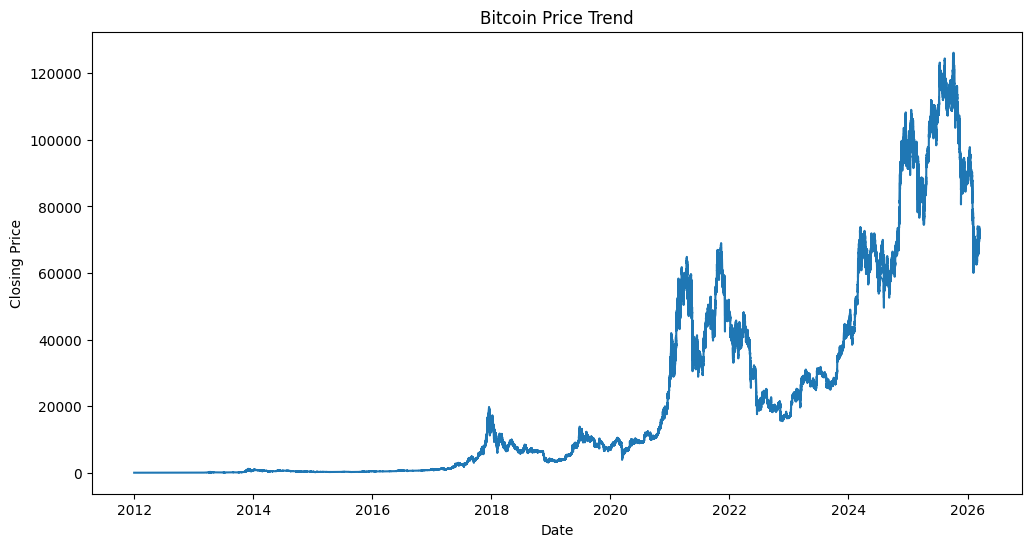

In [8]:
plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['Close'])

plt.title("Bitcoin Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.show()

C:\Users\David S Louis\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


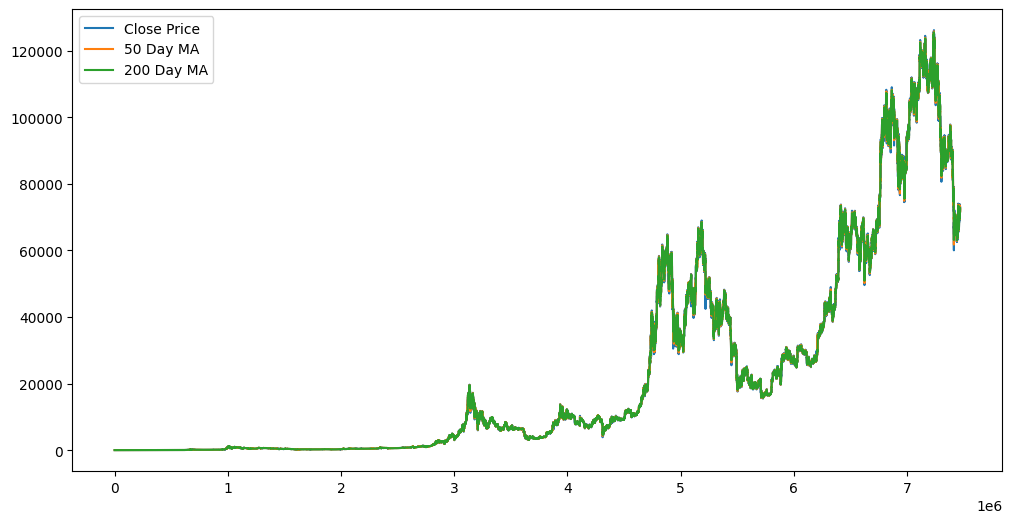

In [9]:
df['MA50'] = df['Close'].rolling(50).mean()
df['MA200'] = df['Close'].rolling(200).mean()

plt.figure(figsize=(12,6))

plt.plot(df['Close'], label='Close Price')
plt.plot(df['MA50'], label='50 Day MA')
plt.plot(df['MA200'], label='200 Day MA')

plt.legend()
plt.show()

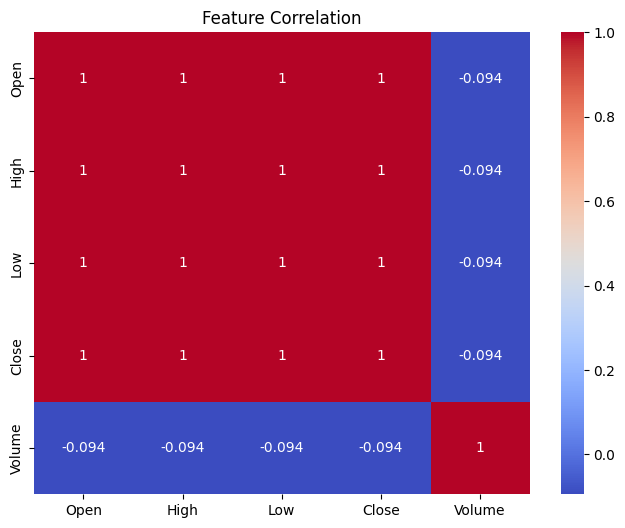

In [10]:
plt.figure(figsize=(8,6))

corr = df[['Open','High','Low','Close','Volume']].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Feature Correlation")

plt.show()

In [11]:
X = df[['Open','High','Low','Volume']]
y = df['Close']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
pred = model.predict(X_test)

In [15]:
mse = mean_squared_error(y_test, pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 134.3796460895242


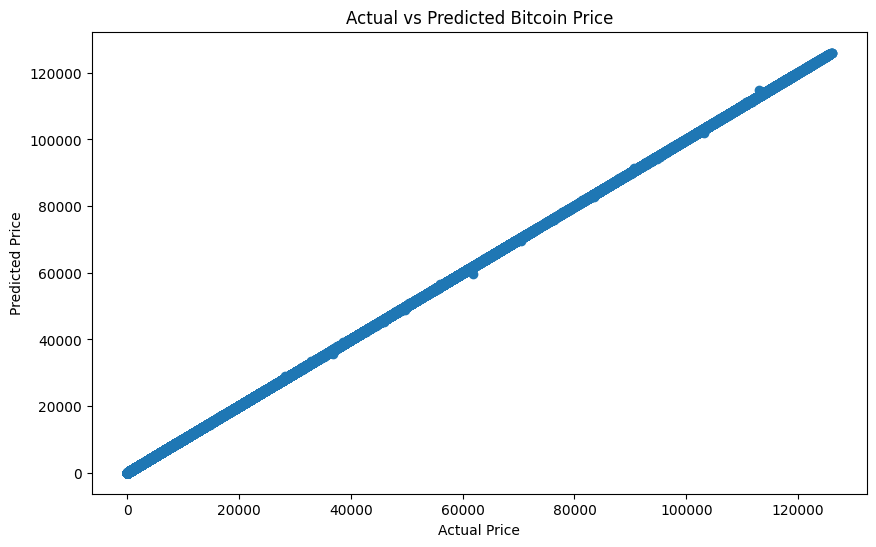

In [16]:
plt.figure(figsize=(10,6))

plt.scatter(y_test, pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Bitcoin Price")

plt.show()